In [1]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
model=ChatOpenAI(model="gpt-4o-mini")

In [3]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [4]:
def gen_joke(state:JokeState):
    prompt=f"Generate a joke on the topic {state['topic']}"
    result=model.invoke(prompt).content
    return {"joke":result}

def explain_joke(state:JokeState):
    prompt=f"Explain the following joke f{state["joke"]}"
    result = model.invoke(prompt).content
    return {"explanation": result}

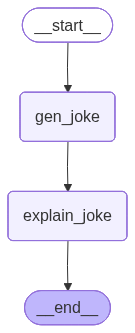

In [5]:
checkpointer=MemorySaver()
graph=StateGraph(JokeState)
graph.add_node("gen_joke",gen_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START,"gen_joke")
graph.add_edge("gen_joke","explain_joke")
graph.add_edge("explain_joke",END)

workflow=graph.compile(checkpointer=checkpointer)
workflow

In [6]:
thread_id="1"
config1={"configurable":{"thread_id":thread_id}}
result=workflow.invoke({"topic":"Monkey"},config=config1)
print(result)

{'topic': 'Monkey', 'joke': 'Why did the monkey like the banana?\n\nBecause it had appeal! 🍌😄', 'explanation': 'This joke is a play on words, utilizing a pun. The humor comes from the double meaning of the word "appeal."\n\n1. **Literal Meaning**: Monkeys are known to enjoy bananas, so the idea that a monkey would "like" a banana makes sense.\n\n2. **Pun**: The word "appeal" can mean both "attraction" or "interest" (as in something that is appealing or attractive) and can also refer to the legal term "appeal," which means to request a higher court to review a decision made by a lower court. \n\nIn this joke, it\'s using "appeal" in the context of being attractive to the monkey — the banana has "appeal" because it is something tasty that the monkey enjoys. The humor arises from the clever play on this word, which leads to a light-hearted and whimsical punchline. The banana emoji emphasizes the subject of the joke, adding to the playful tone.'}


In [7]:
thread_id = "2"
config2 = {"configurable": {"thread_id": thread_id}}
result = workflow.invoke({"topic": "Doctor"}, config=config2)
print(result)

{'topic': 'Doctor', 'joke': 'Why did the doctor carry a red pen?\n\nIn case they needed to draw blood!', 'explanation': "This joke plays on a clever pun involving the word “draw.” In medical contexts, “drawing blood” refers to the process of taking a sample of blood from a patient, usually for lab testing. \n\nOn the other hand, a “red pen” is typically used for writing, correcting, or marking on paper, often associated with teachers. The humor arises from the double meaning of “draw” — a doctor can “draw” blood, but in a different context, they might literally “draw” with a red pen.\n\nThe punchline relies on the element of surprise: the listener might initially think the reason for carrying the pen is practical, only to find out it's based on the play on words!"}


In [8]:
workflow.get_state(config=config1)
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'Monkey', 'joke': 'Why did the monkey like the banana?\n\nBecause it had appeal! 🍌😄', 'explanation': 'This joke is a play on words, utilizing a pun. The humor comes from the double meaning of the word "appeal."\n\n1. **Literal Meaning**: Monkeys are known to enjoy bananas, so the idea that a monkey would "like" a banana makes sense.\n\n2. **Pun**: The word "appeal" can mean both "attraction" or "interest" (as in something that is appealing or attractive) and can also refer to the legal term "appeal," which means to request a higher court to review a decision made by a lower court. \n\nIn this joke, it\'s using "appeal" in the context of being attractive to the monkey — the banana has "appeal" because it is something tasty that the monkey enjoys. The humor arises from the clever play on this word, which leads to a light-hearted and whimsical punchline. The banana emoji emphasizes the subject of the joke, adding to the playful tone.'}, next=(), config={'co

In [9]:
# workflow.get_state(config=config1)
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'Doctor', 'joke': 'Why did the doctor carry a red pen?\n\nIn case they needed to draw blood!', 'explanation': "This joke plays on a clever pun involving the word “draw.” In medical contexts, “drawing blood” refers to the process of taking a sample of blood from a patient, usually for lab testing. \n\nOn the other hand, a “red pen” is typically used for writing, correcting, or marking on paper, often associated with teachers. The humor arises from the double meaning of “draw” — a doctor can “draw” blood, but in a different context, they might literally “draw” with a red pen.\n\nThe punchline relies on the element of surprise: the listener might initially think the reason for carrying the pen is practical, only to find out it's based on the play on words!"}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f134d29-4bfc-68ca-8002-c113c7b748ca'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='20